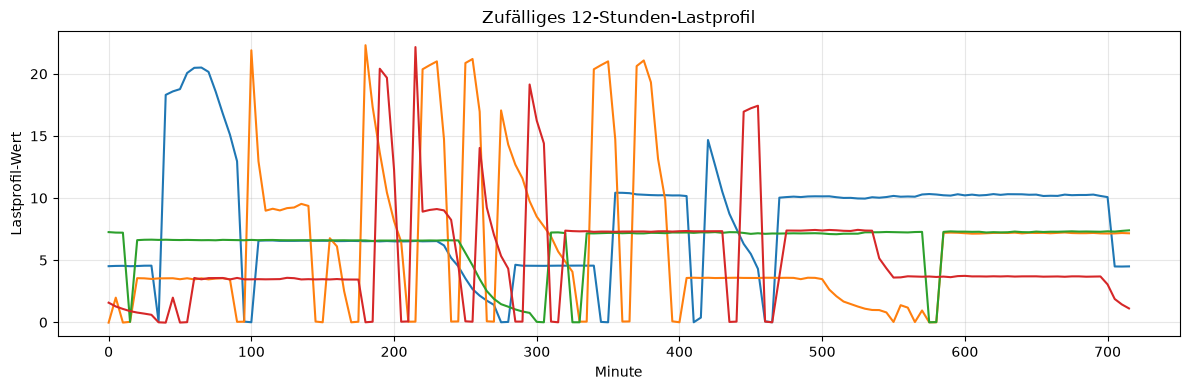

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))

import random_lastprofile_builder as rlb

rlb = importlib.reload(rlb)
build_random_12h_lastprofile = rlb.build_random_12h_lastprofile


def make_random_12h_profile(seed=None):
    """Erzeugt ein zufälliges 12-Stunden-Lastprofil aus den EV-Lastprofilen."""
    profile = build_random_12h_lastprofile(random_state=seed)
    return profile.dropna(subset=["lastprofil"]).reset_index(drop=True)


# Beispielaufruf
profile_12h = make_random_12h_profile(42)
profile_12h_2 = make_random_12h_profile(67)
profile_12h_3 = make_random_12h_profile(13)
profile_12h_4 = make_random_12h_profile(0)

plt.figure(figsize=(12, 4))
plt.plot(profile_12h["minute"], profile_12h["lastprofil"], color="tab:blue", linewidth=1.5)
plt.plot(profile_12h_2["minute"], profile_12h_2["lastprofil"], color="tab:orange", linewidth=1.5)
plt.plot(profile_12h_3["minute"], profile_12h_3["lastprofil"], color="tab:green", linewidth=1.5)
plt.plot(profile_12h_4["minute"], profile_12h_4["lastprofil"], color="tab:red", linewidth=1.5)
plt.title("Zufälliges 12-Stunden-Lastprofil")
plt.xlabel("Minute")
plt.ylabel("Lastprofil-Wert")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Gleichzeitigkeitsfaktor: 0.6517
Pmax (aggregiert): 47.159
Summe der Einzelmaxima: 72.359


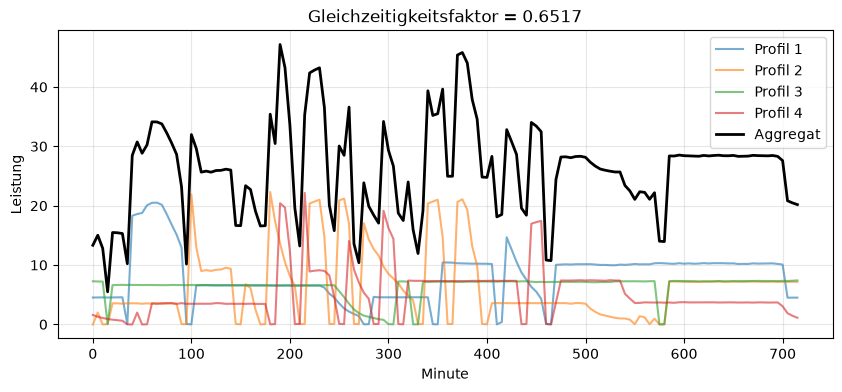

In [4]:
# Berechnung des Gleichzeitigkeitsfaktors für mehrere zufällige Profile
from random_lastprofile_builder import simultaneity_factor, build_random_12h_lastprofile



f, Pmax, Psum = simultaneity_factor(profile_12h, profile_12h_2, profile_12h_3, profile_12h_4, return_components=True)
print(f"Gleichzeitigkeitsfaktor: {f:.4f}")
print(f"Pmax (aggregiert): {Pmax:.3f}")
print(f"Summe der Einzelmaxima: {Psum:.3f}")

# Plot: Einzelprofile + Aggregat
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(profile_12h['minute'], profile_12h['lastprofil'], alpha=0.6, label='Profil 1')
plt.plot(profile_12h_2['minute'], profile_12h_2['lastprofil'], alpha=0.6, label='Profil 2')
plt.plot(profile_12h_3['minute'], profile_12h_3['lastprofil'], alpha=0.6, label='Profil 3')
plt.plot(profile_12h_4['minute'], profile_12h_4['lastprofil'], alpha=0.6, label='Profil 4')
# Aggregat
import numpy as np
common = np.intersect1d(np.intersect1d(profile_12h['minute'], profile_12h_2['minute']), profile_12h_3['minute'])
agg = (profile_12h.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_2.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_3.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_4.set_index('minute').reindex(common)['lastprofil'].to_numpy())
plt.plot(common, agg, color='k', linewidth=2, label='Aggregat')
plt.legend()
plt.xlabel('Minute')
plt.ylabel('Leistung')
plt.title(f'Gleichzeitigkeitsfaktor = {f:.4f}')
plt.grid(alpha=0.3)
plt.show()

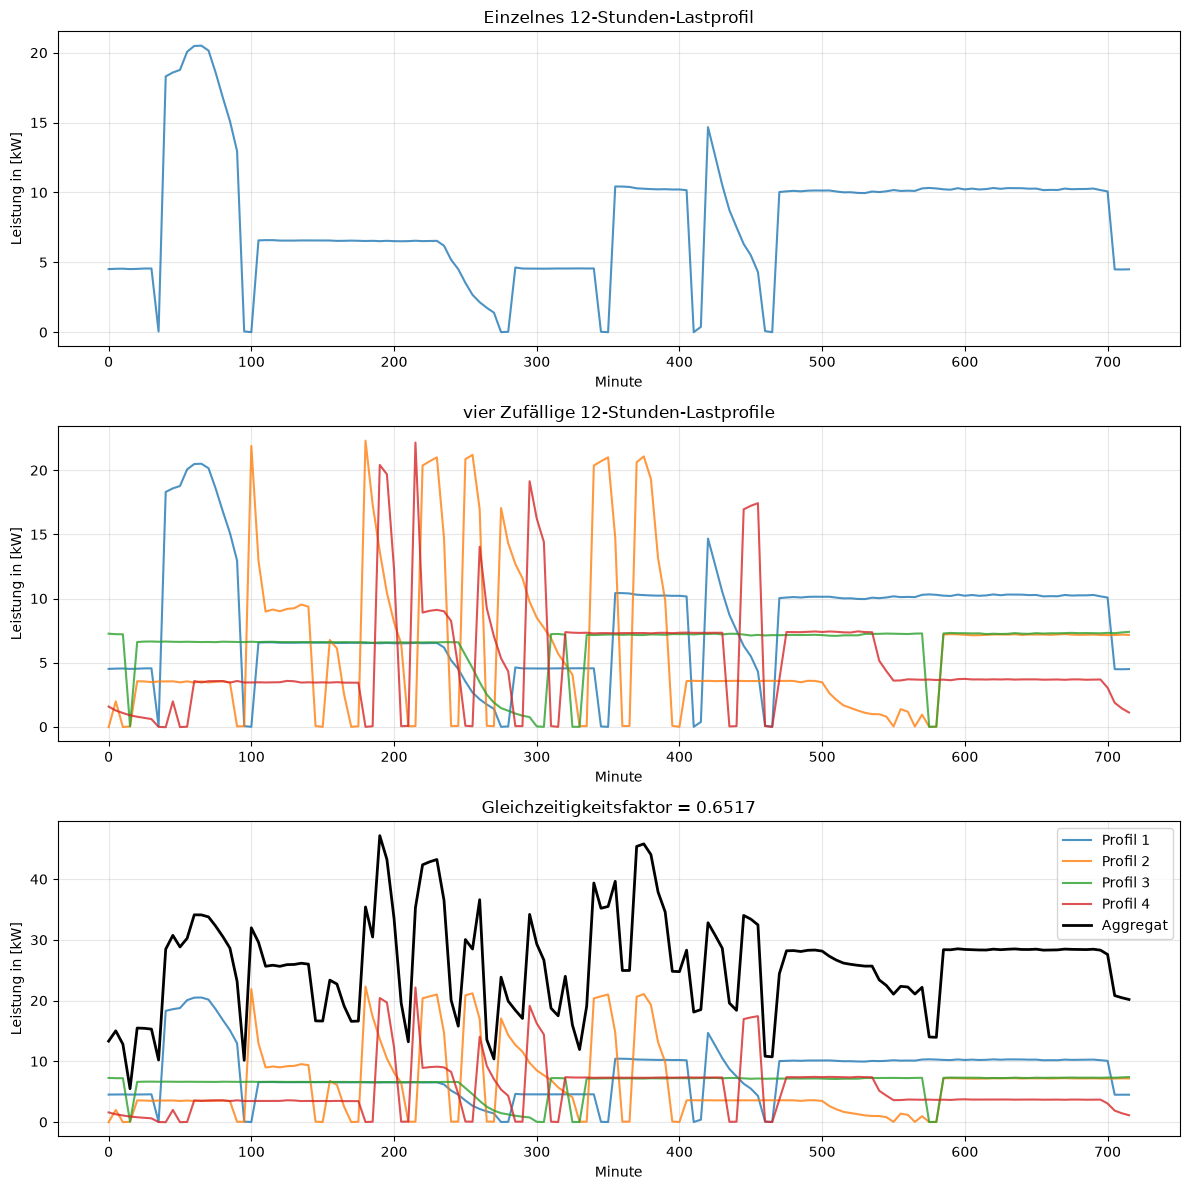

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Subplot 1: einzelnes Lastprofil
axes[0].plot(profile_12h["minute"], profile_12h["lastprofil"], color="tab:blue", linewidth=1.5, alpha=0.8)
axes[0].set_title("Einzelnes 12-Stunden-Lastprofil")
axes[0].set_xlabel("Minute")
axes[0].set_ylabel("Leistung in [kW]")
axes[0].grid(True, alpha=0.3)

# Subplot 2: alle 4 Lastprofile
axes[1].plot(profile_12h["minute"], profile_12h["lastprofil"], color="tab:blue", linewidth=1.5, alpha=0.8)
axes[1].plot(profile_12h_2["minute"], profile_12h_2["lastprofil"], color="tab:orange", linewidth=1.5, alpha=0.8)
axes[1].plot(profile_12h_3["minute"], profile_12h_3["lastprofil"], color="tab:green", linewidth=1.5, alpha=0.8)
axes[1].plot(profile_12h_4["minute"], profile_12h_4["lastprofil"], color="tab:red", linewidth=1.5, alpha=0.8)
axes[1].set_title("vier Zufällige 12-Stunden-Lastprofile")
axes[1].set_xlabel("Minute")
axes[1].set_ylabel("Leistung in [kW]")
axes[1].grid(True, alpha=0.3)

# Subplot 3: Gleichzeitigkeitsfaktor (Einzelprofile + Aggregat)

common = np.intersect1d(np.intersect1d(profile_12h['minute'], profile_12h_2['minute']), profile_12h_3['minute'])
agg = (profile_12h.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_2.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_3.set_index('minute').reindex(common)['lastprofil'].to_numpy() +
       profile_12h_4.set_index('minute').reindex(common)['lastprofil'].to_numpy())

axes[2].plot(profile_12h["minute"], profile_12h["lastprofil"], color='tab:blue', linewidth=1.5, alpha=0.8, label='Profil 1')
axes[2].plot(profile_12h_2["minute"], profile_12h_2["lastprofil"], color='tab:orange', linewidth=1.5, alpha=0.8, label='Profil 2')
axes[2].plot(profile_12h_3["minute"], profile_12h_3["lastprofil"], color='tab:green', linewidth=1.5, alpha=0.8, label='Profil 3')
axes[2].plot(profile_12h_4["minute"], profile_12h_4["lastprofil"], color='tab:red', linewidth=1.5, alpha=0.8, label='Profil 4')
axes[2].plot(common, agg, color='k', linewidth=2, label='Aggregat')
axes[2].legend()
axes[2].set_title(f'Gleichzeitigkeitsfaktor = {f:.4f}')
axes[2].set_xlabel('Minute')
axes[2].set_ylabel('Leistung in [kW]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()